In [1]:
import warnings

import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import VimeoVideo
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.utils.validation import check_is_fitted

warnings.simplefilter(action="ignore", category=FutureWarning)

In this lesson, we're going to build on the work we did in the previous lesson. We're going to create a more complex wrangle function, use it to clean 
more data, and build a model that considers more features when predicting apartment price.

In [2]:
def wrangle(filepath):
    # Read CSV file
    df = pd.read_csv(filepath)

    # Subset data: Apartments in "Capital Federal", less than 400,000
    mask_ba = df["place_with_parent_names"].str.contains("Capital Federal")
    mask_apt = df["property_type"] == "apartment"
    mask_price = df["price_aprox_usd"] < 400_000
    df = df[mask_ba & mask_apt & mask_price]

    # Subset data: Remove outliers for "surface_covered_in_m2"
    low, high = df["surface_covered_in_m2"].quantile([0.1, 0.9])
    mask_area = df["surface_covered_in_m2"].between(low, high)
    df = df[mask_area]
    #split "lat-lon" 
    df[["lat", "lon" ]]= df["lat-lon"].str.split(',', expand=True).astype(float)
    df.drop(columns="lat-lon", inplace=True)

    

    return df

In [ ]:
Task 2.2.1: Use your wrangle function to create a DataFrame frame1 from the CSV file data/buenos-aires-real-estate-1.csv.

In [3]:
frame1 = wrangle("data/buenos-aires-real-estate-1.csv")
print(frame1.info())
frame1.head()

<class 'pandas.core.frame.DataFrame'>
Index: 1343 entries, 4 to 8604
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   1343 non-null   object 
 1   property_type               1343 non-null   object 
 2   place_with_parent_names     1343 non-null   object 
 3   price                       1343 non-null   float64
 4   currency                    1343 non-null   object 
 5   price_aprox_local_currency  1343 non-null   float64
 6   price_aprox_usd             1343 non-null   float64
 7   surface_total_in_m2         965 non-null    float64
 8   surface_covered_in_m2       1343 non-null   float64
 9   price_usd_per_m2            927 non-null    float64
 10  price_per_m2                1343 non-null   float64
 11  floor                       379 non-null    float64
 12  rooms                       1078 non-null   float64
 13  expenses                    349 non-nu

,operation,property_type,place_with_parent_names,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon
4,sell,apartment,|Argentina|Capital Federal|Chacarita|,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,-34.584651,-58.454693
9,sell,apartment,|Argentina|Capital Federal|Villa Luro|,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,-34.638979,-58.500115
29,sell,apartment,|Argentina|Capital Federal|Caballito|,118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,-34.615847,-58.459957
40,sell,apartment,|Argentina|Capital Federal|Constitución|,57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364.0,http://constitucion.properati.com.ar/k2f0_vent...,-34.625222,-58.382382
41,sell,apartment,|Argentina|Capital Federal|Once|,90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450.0,http://once.properati.com.ar/suwa_venta_depart...,-34.610610,-58.412511


In [ ]:
For our model, we're going to consider apartment location, specifically, latitude and longitude. Looking at the output from frame1.info(), we can see 
that the location information is in a single column where the data type is object (pandas term for str in this case). In order to build our model, we
need latitude and longitude to each be in their own column where the data type is float.

In [ ]:
Task 2.2.2: Add to the wrangle function above so that, in the DataFrame it returns, the "lat-lon" column is replaced by separate "lat" and "lon" columns.
Don't forget to also drop the "lat-lon" column. Be sure to rerun all the cells above before you continue.

In [ ]:
frame1["lat-lon"].str.split(',', expand=True).astype(float).info()

In [ ]:
Now that our wrangle function is working, let's use it to clean more data!

In [ ]:
Task 2.2.3: Use you revised wrangle function create a DataFrames frame2 from the file data/buenos-aires-real-estate-2.csv.

In [4]:
frame2 = wrangle("data/buenos-aires-real-estate-2.csv")

In [ ]:
As you can see, using a function is much quicker than cleaning each file individually like we did in the last project. Let's combine our DataFrames so
we can use then to train our model.

In [ ]:
Task 2.2.4: Use pd.concat to concatenate frame1 and frame2 into a new DataFrame df. Make sure you set the ignore_index argument to True.

In [5]:
df = pd.concat([frame1, frame2], ignore_index=True)
print(df.info())
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 17 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   operation                   2658 non-null   object 
 1   property_type               2658 non-null   object 
 2   place_with_parent_names     2658 non-null   object 
 3   price                       2658 non-null   float64
 4   currency                    2658 non-null   object 
 5   price_aprox_local_currency  2658 non-null   float64
 6   price_aprox_usd             2658 non-null   float64
 7   surface_total_in_m2         1898 non-null   float64
 8   surface_covered_in_m2       2658 non-null   float64
 9   price_usd_per_m2            1818 non-null   float64
 10  price_per_m2                2658 non-null   float64
 11  floor                       769 non-null    float64
 12  rooms                       2137 non-null   float64
 13  expenses                    688 n

,operation,property_type,place_with_parent_names,price,currency,price_aprox_local_currency,price_aprox_usd,surface_total_in_m2,surface_covered_in_m2,price_usd_per_m2,price_per_m2,floor,rooms,expenses,properati_url,lat,lon
0,sell,apartment,|Argentina|Capital Federal|Chacarita|,129000.0,USD,1955949.6,129000.0,76.0,70.0,1697.368421,1842.857143,NaN,NaN,NaN,http://chacarita.properati.com.ar/10qlv_venta_...,-34.584651,-58.454693
1,sell,apartment,|Argentina|Capital Federal|Villa Luro|,87000.0,USD,1319128.8,87000.0,48.0,42.0,1812.500000,2071.428571,NaN,NaN,NaN,http://villa-luro.properati.com.ar/12m82_venta...,-34.638979,-58.500115
2,sell,apartment,|Argentina|Capital Federal|Caballito|,118000.0,USD,1789163.2,118000.0,NaN,54.0,NaN,2185.185185,NaN,2.0,NaN,http://caballito.properati.com.ar/11wqh_venta_...,-34.615847,-58.459957
3,sell,apartment,|Argentina|Capital Federal|Constitución|,57000.0,USD,864256.8,57000.0,42.0,42.0,1357.142857,1357.142857,5.0,2.0,364.0,http://constitucion.properati.com.ar/k2f0_vent...,-34.625222,-58.382382
4,sell,apartment,|Argentina|Capital Federal|Once|,90000.0,USD,1364616.0,90000.0,57.0,50.0,1578.947368,1800.000000,NaN,3.0,450.0,http://once.properati.com.ar/suwa_venta_depart...,-34.610610,-58.412511


Explore

In the last lesson, we built a simple linear model that predicted apartment price based on one feature, "surface_covered_in_m2". In this lesson, we're 
building a multiple linear regression model that predicts price based on two features, "lon" and "lat". This means that our data visualizations now have to communicate three pieces of information: Longitude, latitude, and price. How can we represent these three attributes on a two-dimensional screen?
One option is to incorporate color into our scatter plot. For example, in the Mapbox scatter plot below, the location of each point represents latitude
and longitude, and color represents price.

Task 2.2.5: Complete the code below to create a Mapbox scatter plot that shows the location of the apartments in df.
    
A scatter plot is a graph that uses dots to represent values for two different numeric variables. The position of each dot on the horizontal and 
vertical axis indicates values for an individual data point. Scatter plots are used to observe relationships between variables, and are especially 
useful if you're looking for correlations.    

A mapbox scatter plot is a special kind of scatter plot that allows you to create scatter plots in two dimensions and then superimpose them on top of 
a map. Our mexico-city-real-estate-1.csv dataset is a good place to start, because it includes location data. After importing the dataset and removing 
rows with missing data, split the lat-lon column into two separate columns: one for latitude and the other for longitude. Then use these to make 
a mapbox plot. Unfortunately, at present this type of plot does not easily allow for marker shape to vary based on a column of the DataFrame.    

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_17004\118813560.py:1: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


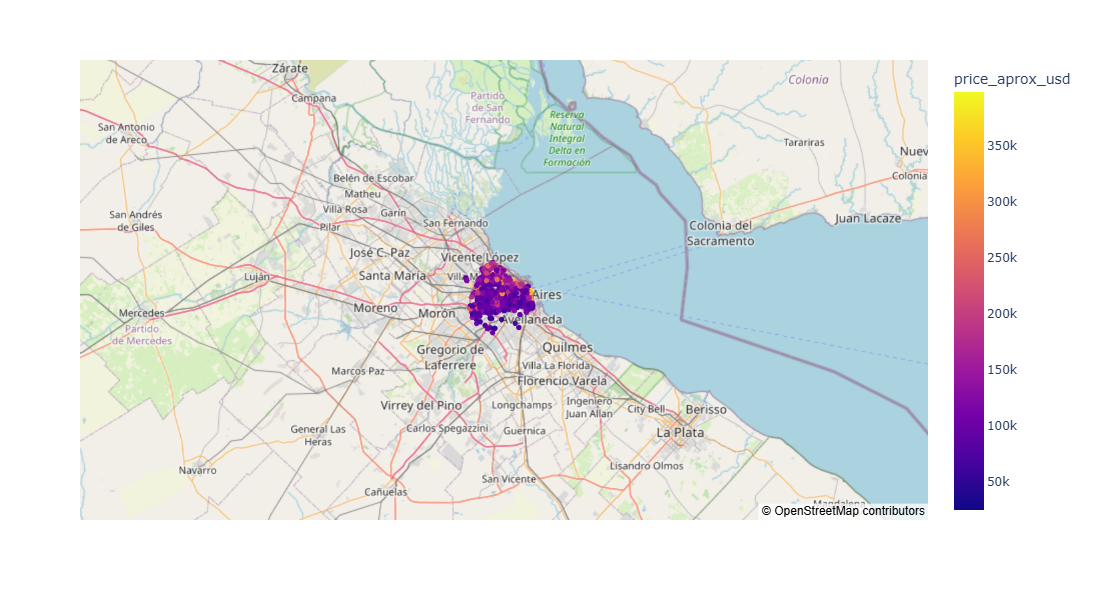

In [7]:
fig = px.scatter_mapbox(
    df,  # Our DataFrame
    lat= "lat",
    lon= "lon",
    width=600,  # Width of map
    height=600,  # Height of map
    color= "price_aprox_usd",
    hover_data=["price_aprox_usd"],  # Display price when hovering mouse over house
)

fig.update_layout(mapbox_style="open-street-map")

fig.show()

Another option is to add a third dimension to our scatter plot. We can plot longitude on the x-axis and latitude on the y-axis (like we do in the map above), and then add a z-axis with price. 

In [ ]:
Task 2.2.6: Complete the code below to create a 3D scatter plot, with "lon" on the x-axis, "lat" on the y-axis, and "price_aprox_usd" on the z-axis.

In [ ]:
3D scatter plot: Scatter plots can summarize information in a DataFrame. Three dimensional scatter plots look great, but be careful: it can be difficult
for people who might not be sure what they're looking at to accurately determine values of points in the plot. Still, scatter plots are useful for 
displaying relations hips between three quantities that would be more difficult to observe in a two dimensional plot.

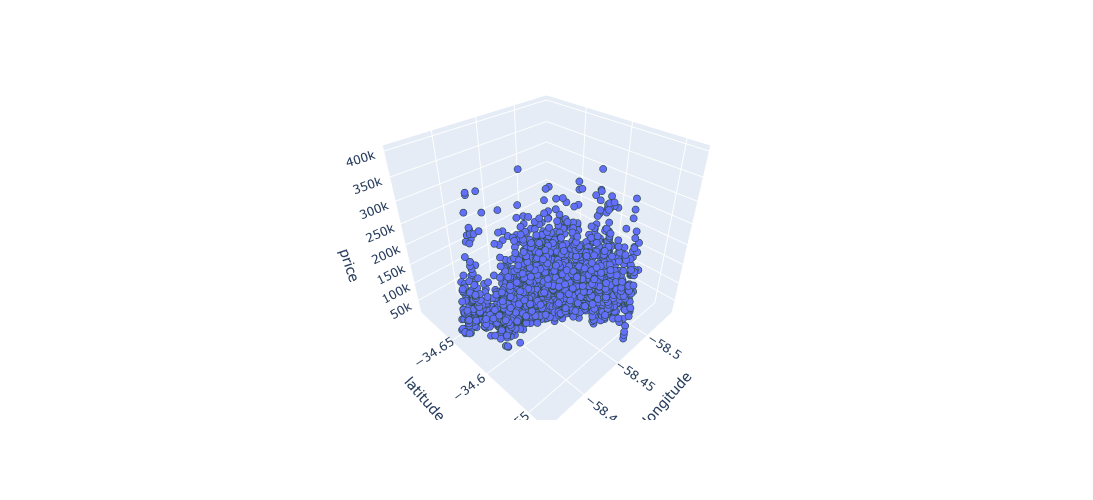

In [8]:
# Create 3D scatter plot
fig = px.scatter_3d(
    df,
    x= "lon",
    y= "lat",
    z= "price_aprox_usd",
    labels={"lon": "longitude", "lat": "latitude", "price_aprox_usd": "price"},
    width=600,
    height=500,
)

# Refine formatting
fig.update_traces(
    marker={"size": 4, "line": {"width": 2, "color": "DarkSlateGrey"}},
    selector={"mode": "markers"},
)

# Display figure
fig.show()

3D visualizations are often harder for someone to interpret than 2D visualizations. We're using one here because it will help us visualize our model 
once it's built, but as a rule, it's better to stick with 2D when your communicating with an audience.

Split

Even though we're building a different model, the steps we follow will be the same. Let's separate our features (latitude and longitude) from our target (price). 

In [ ]:
Task 2.2.7: Create the feature matrix named X_train. It should contain two features: ["lon", "lat"].

In [9]:
features = ["lon", "lat"]
X_train = df[features]
X_train.shape

(2658, 2)

In [ ]:
Task 2.2.8: Create the target vector named y_train, which you'll use to train your model. Your target should be "price_aprox_usd". Remember that, in 
most cases, your target vector should be one-dimensional.

In [10]:
target = "price_aprox_usd"
y_train = df[target]
y_train.shape

(2658,)

In [ ]:
Build Model

Baseline

Again, we need to set a baseline so we can evaluate our model's performance. You'll notice that the value of y_mean is not exactly the same as it was 
in the previous lesson. That's because we've added more observations to our training data.

In [ ]:
Task 2.2.9: Calculate the mean of your target vector y_train and assign it to the variable y_mean.

In [11]:
y_mean = y_train.mean()

In [ ]:
Task 2.2.10: Create a list named y_pred_baseline that contains the value of y_mean repeated so that it's the same length at y_train.

In [12]:
y_pred_baseline = [y_mean] * len(y_train)

In [ ]:
Task 2.2.11: Calculate the baseline mean absolute error for your predictions in y_pred_baseline as compared to the true targets in y_train.

In [ ]:
Performance Metrics
In statistics, an error is the difference between a measurement and reality. There may not be any difference at all, but there's usually something not 
quite right, and we need to account for that in our model. To do that, we need to figure out the mean absolute error (MAE). Absolute error is the error
in a single measurement, and mean absolute error is the average error over the course of several measurements.

Imagine that you're buying some bananas. The store charges for fruit based on weight, so you put your bananas on a scale before you head off to pay for
them. The scale says they weigh 1.2 kilos, but your innate sense of weight tells you that they actually weight 0.9 kilos. The absolute error in that
measurement would be 0.3 kilos. It can go the other way too: maybe you know the bananas weight 1.2 kilos, but the scale says they were 0.9 kilos. In 
that case, the absolute error would still be 0.3 kilos, because even though the numerical difference is -0.3, absolute values are always positive; all 
you have to do is disregard the - sign.
    
Let's keep going: you're sure the bananas don't weight 1.2 kilos, so you weigh them again. This time, the scale 
says 1.0 kilos. That's still wrong, so you weigh the bananas a third time, and now the scale says 2.3 kilos. Since the actual weight of your bananas 
hasn't changed, you now have a set of three absolute errors: 0.3, 0.1, and 1.4. If we average those errors together, we get 0.6, which is the mean 
absolute error for your banana data.

In [13]:
mae_baseline = mean_absolute_error(y_pred_baseline, y_train)

print("Mean apt price", round(y_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

Mean apt price 134732.97
Baseline MAE: 45422.75


In [ ]:
Iterate

Take a moment to scroll up to the output for df.info() and look at the values in the "Non-Null Count" column. Because of the math it uses, a linear 
regression model can't handle observations where there are missing values. Do you see any columns where this will be a problem? In the last project, we
simply dropped rows that contained NaN values, but this isn't ideal. Models generally perform better when they have more data to train with, so every 
row is precious. Instead, we can fill in these missing values using information we get from the whole column — a process called imputation. There are 
many different strategies for imputing missing values, and one of the most common is filling in the missing values with the mean of the column. In 
addition to predictors like LinearRegression, scikit-learn also has transformers that help us deal with issues like missing values. Let's see how one 
works, and then we'll add it to our model.

In [ ]:
Task 2.2.12: Instantiate a SimpleImputer named imputer.

In [ ]:
Imputation

Datasets are often incomplete or missing entries. If the dataset is large and the missing entries are few, then the missing entries aren't all that 
important. But sometimes, it might be useful to include data with missing entries by finding a way to impute the missing entries in a row or column of
a DataFrame. For example, you might use extrapolation when the data points have a pattern, or you might approximate the missing values by mean values.

In [14]:
imputer = SimpleImputer()

In [ ]:
Just like a predictor, a transformer has a fit method. In the case of our SimpleImputer, this is the step where it calculates the mean values for each
numerical column.

In [ ]:
Task 2.2.13: Fit your transformer imputer to the feature matrix X.

In [15]:
imputer.fit(X_train)

,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False


In [ ]:
Here's where transformers diverge from predictors. Instead of using a method like predict, we use the transform method. This is the step where the 
transformer fills in the missing values with the means it's calculated.

In [ ]:
Task 2.2.14: Use your imputer to transform the feature matrix X_train. Assign the transformed data to the variable XT_train.

In [16]:
XT_train = imputer.transform(X_train)
pd.DataFrame(XT_train, columns=X_train.columns).info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2658 entries, 0 to 2657
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   lon     2658 non-null   float64
 1   lat     2658 non-null   float64
dtypes: float64(2)
memory usage: 41.7 KB


In [ ]:
Okay! Our data is free of missing values, and we have a good sense for how predictors work in scikit-learn. However, the truth is you'll rarely do data
transformations this way. Why? A model may require multiple transformers, and doing all those transformations one-by-one is slow and likely to lead to 
errors. 🤦‍♀️ Instead, we can combine our transformer and predictor into a single object called a pipeline. 

In [ ]:
Task 2.2.15: Create a pipeline named model that contains a SimpleImputer transformer followed by a LinearRegression predictor.

In [18]:
model = make_pipeline(
    SimpleImputer(),
    LinearRegression()
)

In [ ]:
With our pipeline assembled, we use the fit method, which will train the transformer, transform the data, then pass the transformed data to the
predictor for training, all in one step. Much easier!

In [ ]:
Task 2.2.16: Fit your model to the data, X_train and y_train.

In [19]:
model.fit(X_train, y_train)

,steps,"[('simpleimputer', ...), ('linearregression', ...)]"
,transform_input,None
,memory,None
,verbose,False
,missing_values,nan
,strategy,'mean'
,fill_value,None
,copy,True
,add_indicator,False
,keep_empty_features,False
,fit_intercept,True


In [ ]:
Evaluate

As always, we'll start by evaluating our model's performance on the training data.

In [ ]:
Task 2.2.17: Using your model's predict method, create a list of predictions for the observations in your feature matrix X_train. Name this list
y_pred_training.

In [20]:
y_pred_training = model.predict(X_train)

In [ ]:
Task 2.2.18: Calculate the training mean absolute error for your predictions in y_pred_training as compared to the true targets in y_train.

In [21]:
mae_training = mean_absolute_error(y_train, y_pred_training)
print("Training MAE:", round(mae_training, 2))

Training MAE: 42962.72


In [ ]:
It looks like our model performs a little better than the baseline. This suggests that latitude and longitude aren't as strong predictors of price as 
size is.
Now let's check our test performance. Remember, once we test our model, there's no more iteration allowed.

In [ ]:
Task 2.2.19: Run the code below to import your test data buenos-aires-test-features.csv into a DataFrame and generate a Series of predictions using 
your model. After the code runs successfully, click on the Check Activity button on the left pane to verify your predictions.

In [ ]:
Generalization
Notice that we tested the model with a dataset that's different from the one we used to train the model. Machine learning models are useful if they 
allow you to make predictions about data other than what you used to train your model. We call this concept generalization. By testing your model with
different data than you used to train it, you're checking to see if your model can generalize. Most machine learning models do not generalize to all 
possible types of input data, so they should be used with care. On the other hand, machine learning models that don't generalize to make predictions 
for at least a restricted set of data aren't very useful.

In [22]:
X_test = pd.read_csv("data/buenos-aires-test-features.csv")[features]
y_pred_test = pd.Series(model.predict(X_test))
y_pred_test.head()

FileNotFoundError: [Errno 2] No such file or directory: 'data/buenos-aires-test-features.csv'

In [ ]:
Again, we want our test performance to be about the same as our training performance, but it's OK if it's not quite as good.

In [ ]:
Communicate Results
Let's take a look at the equation our model has come up with for predicting price based on latitude and longitude. We'll need to expand on our formula 
to account for both features.

Equation: y = beta 0 + beta 1 * x

In [ ]:
Task 2.2.20: Extract the intercept and coefficients for your model.

Linear regression is a way to predict the value of some a target variable by fitting a line that best describes the relationship between Big X and 
little y for the values we already have. If you remember y = mx + b from Algebra, it's the same thing; the y is the intercept, and the b is the beta 
coefficient. The beta coefficient tells us what change we can expect to see in X for every one-unit increase in y. If that doesn't seem familiar to you,
don't worry about it; we'll give you everything you need to know.    

In [23]:
intercept = model.named_steps["linearregression"].intercept_.round(0)
coefficients = model.named_steps["linearregression"].coef_.round(0)

In [ ]:
Task 2.2.21: Complete the code below and run the cell to print the equation that your model has determined for predicting apartment price based on 
latitude and longitude.

In [ ]:
We usually use print to examine output in Python, but most of the examples we've been printing have been relatively short. Formatted strings are helpful
for all sorts of reasons, but when we're assembling and formatting a long string, using the print function can be difficult and time-consuming. Along
the same lines, it's also useful to directly evaluate variables and expressions within strings. To do those things, we create f"" strings. The code looks
like this:

In [ ]:
Task 2.2.22: Complete the code below to create a 3D scatter plot, with "lon" on the x-axis, "lat" on the y-axis, and "price_aprox_usd" on the z-axis.

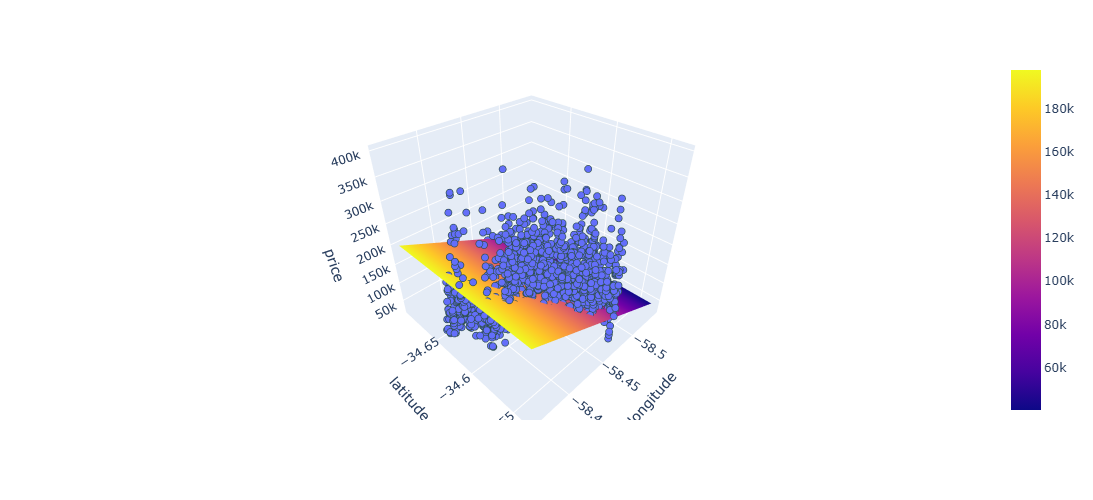

In [24]:
# Create 3D scatter plot
fig = px.scatter_3d(
    df,
    x= "lon",
    y= "lat",
    z= "price_aprox_usd",
    labels={"lon": "longitude", "lat": "latitude", "price_aprox_usd": "price"},
    width=600,
    height=500,
)

# Create x and y coordinates for model representation
x_plane = np.linspace(df["lon"].min(), df["lon"].max(), 10)
y_plane = np.linspace(df["lat"].min(), df["lat"].max(), 10)
xx, yy = np.meshgrid(x_plane, y_plane)

# Use model to predict z coordinates
z_plane = model.predict(pd.DataFrame({"lon": x_plane, "lat": y_plane}))
zz = np.tile(z_plane, (10, 1))

# Add plane to figure
fig.add_trace(go.Surface(x=xx, y=yy, z=zz))

# Refine formatting
fig.update_traces(
    marker={"size": 4, "line": {"width": 2, "color": "DarkSlateGrey"}},
    selector={"mode": "markers"},
)

# Display figure
fig.show()